# Bandit パラメータ sweep: Q 学習の学習曲線

2 本腕バンディット上の Q 学習について、学習率 α と逆温度 β を振り、
学習曲線（最適腕を選んだ割合）と累積後悔（cumulative regret）がどう変わるかを比較する。

| セクション | 内容 |
|---|---|
| 1 | セットアップ |
| 2 | 実行パラメータ設定 |
| 3 | run.jl 実行 |
| 4 | 結果読み込み・集計 |
| 5 | 学習曲線の比較 |
| 6 | 最終性能サマリ |
| 7 | 累積 regret の比較 |

## 1. セットアップ

In [ ]:
import Pkg
Pkg.activate(joinpath(@__DIR__, ".."); io=devnull)
Pkg.instantiate(; io=devnull)
using DrWatson, CSV, DataFrames, Plots, Statistics, Printf

# モデル関数（softmax_choice / run_bandit）を読み込む
# 保存ロジック（save_sim）は src/io.jl にあるが、notebook では run.jl 経由で使うため不要
include(srcdir("bandit.jl"))

## 2. 実行パラメータ設定

学習率 α と逆温度 β の組み合わせを sweep する。

In [ ]:
paramsets = [
    Dict(
        :seed         => 42,
        :n_trials     => 100,
        :n_reps       => 200,
        :reward_probs => [0.2, 0.8],
        :alpha        => a,
        :beta         => b,
    )
    for a in [0.1, 0.3, 0.6]
    for b in [2.0, 5.0]
]

println("Total: $(length(paramsets))")
paramsets

## 3. run.jl 実行

各パラメータ条件について `scripts/run.jl` をサブプロセスで実行し、
結果を `datadir("sims")` に CSV 保存する。

In [ ]:
run_script = projectdir("scripts", "run.jl")
jl_exe = joinpath(Sys.BINDIR, "julia")

for p in paramsets
    fixed = (p[:seed], p[:n_trials], p[:n_reps], p[:alpha], p[:beta])
    probs = p[:reward_probs]
    cmd   = `$jl_exe $run_script $(fixed...) $(probs...)`
    println("Running: julia scripts/run.jl $(join(fixed, " ")) $(join(probs, " "))")
    run(cmd)
end

## 4. 結果読み込み・集計

保存した CSV を `savename` で特定して読み込み、1 つの DataFrame にまとめる。

In [ ]:
sim_dir = datadir("sims")

rows = DataFrame[]
for p in paramsets
    params = Dict(
        "alpha"    => p[:alpha],
        "beta"     => p[:beta],
        "n_arms"   => length(p[:reward_probs]),
        "seed"     => p[:seed],
        "n_trials" => p[:n_trials],
        "n_reps"   => p[:n_reps],
    )
    f = joinpath(sim_dir, savename("bandit", params, "csv"))
    isfile(f) || (println("Missing: ", f); continue)
    push!(rows, CSV.read(f, DataFrame))
end

isempty(rows) && error("No result files were loaded.")
df = vcat(rows...)
println("Rows: $(nrow(df))")
first(df, 5)

In [12]:
agg = combine(
    groupby(df, [:alpha, :beta]),
    :p_optimal => last => :final_p_optimal,
    :p_optimal => mean => :mean_p_optimal,
)
sort!(agg, [:alpha, :beta])
agg

Row,alpha,beta,final_p_optimal,mean_p_optimal
,Float64,Float64,Float64,Float64
1,0.1,2.0,0.75,0.73395
2,0.1,5.0,0.96,0.9179
3,0.3,2.0,0.735,0.75045
4,0.3,5.0,0.93,0.9271
5,0.6,2.0,0.715,0.74735
6,0.6,5.0,0.875,0.8983


## 5. 学習曲線の比較

パラメータ条件ごとに、最適腕を選んだ割合の推移を重ねて描画する。

In [ ]:
plt = plot(;
    xlabel = "Trial",
    ylabel = "P(optimal)",
    title  = "Q-learning learning curves",
    ylim   = (0, 1),
    legend = :bottomright,
    lw     = 2,
)

for p in paramsets
    sub = filter(r -> r.alpha == p[:alpha] && r.beta == p[:beta], df)
    isempty(sub) && continue
    sort!(sub, :trial)
    plot!(plt, sub.trial, sub.p_optimal; label = "α=$(p[:alpha]), β=$(p[:beta])")
end

savefig(plt, plotsdir("learning_curves_sweep.png"))
plt

## 6. 最終性能サマリ

In [14]:
println("=== 最終性能（最後の試行の P(optimal)）===\n")
for p in paramsets
    sub = filter(r -> r.alpha == p[:alpha] && r.beta == p[:beta], df)
    isempty(sub) && continue
    sort!(sub, :trial)
    @printf("  \u03b1=%.1f  \u03b2=%.1f  final=%.3f  mean=%.3f\n",
        p[:alpha], p[:beta], sub.p_optimal[end], mean(sub.p_optimal))
end

=== 最終性能（最後の試行の P(optimal)）===

  α=0.1  β=2.0  final=0.750  mean=0.734
  α=0.1  β=5.0  final=0.960  mean=0.918
  α=0.3  β=2.0  final=0.735  mean=0.750
  α=0.3  β=5.0  final=0.930  mean=0.927
  α=0.6  β=2.0  final=0.715  mean=0.747
  α=0.6  β=5.0  final=0.875  mean=0.898


## 7. 累積 regret の比較

**cumulative regret（累積後悔）** = 各試行の `p_best - p_choice` の累積和。

- 傾きが急 → 最適腕を選べていない（探索が足りない or 学習が遅い）
- 傾きが緩やか → 早い段階で最適腕を特定できている

理想的なエージェントは「早めに最適腕を見つけてからは regret をほぼ増やさない」ため、
カーブが途中で頭打ちに近くなる。

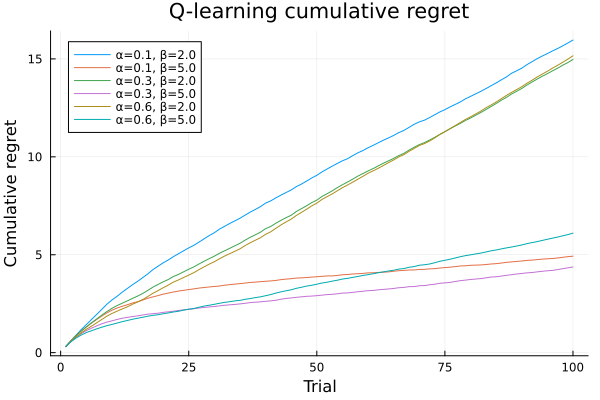

In [15]:
plt_reg = plot(;
    xlabel = "Trial",
    ylabel = "Cumulative regret",
    title  = "Q-learning cumulative regret",
    legend = :topleft,
    lw     = 2,
)

for p in paramsets
    sub = filter(r -> r.alpha == p[:alpha] && r.beta == p[:beta], df)
    isempty(sub) && continue
    sort!(sub, :trial)
    plot!(plt_reg, sub.trial, cumsum(sub.regret);
        label = "α=$(p[:alpha]), β=$(p[:beta])")
end

savefig(plt_reg, plotsdir("cumulative_regret_sweep.png"))
plt_reg